# Resort Customer Churn Modeling

This notebook builds a complete churn prediction workflow for the resort dataset:

- load the training and scoring data from the GitHub raw CSV URLs
- inspect missingness and target balance
- clean problematic values and engineer customer, booking, room, promotion, and spend features
- compare several classification algorithms with stratified cross-validation
- tune the best algorithm with Optuna using cross-validated ROC AUC
- choose a probability threshold from out-of-fold predictions
- train the final model and write `submission.csv` with `GuestID` and a 0/1 `Churned` prediction

## 1. Setup

If `optuna` is not installed in your environment, install it first with:

```python
%pip install optuna
```

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TARGET = "Churned"
ID_COLUMN = "GuestID"

TRAIN_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv"
TEST_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_test.csv"

LOCAL_TRAIN_PATH = Path("data/resort_train.csv")
LOCAL_TEST_PATH = Path("data/resort_test.csv")
SUBMISSION_PATH = Path("submission.csv")

CV_SPLITS = 3
N_TRIALS = 8

## 2. Load The Data

The notebook reads from the GitHub raw URLs. A local fallback is included so the notebook still runs if the CSVs have already been downloaded into `data/`.

In [2]:
def read_csv_with_fallback(url: str, fallback_path: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(url)
        print(f"Loaded {len(df):,} rows from {url}")
        return df
    except Exception as exc:
        if fallback_path.exists():
            print(f"Could not load {url}. Using local fallback: {fallback_path}")
            print(f"Original load error: {type(exc).__name__}: {exc}")
            return pd.read_csv(fallback_path)
        raise


train = read_csv_with_fallback(TRAIN_URL, LOCAL_TRAIN_PATH)
test = read_csv_with_fallback(TEST_URL, LOCAL_TEST_PATH)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
display(train.head())
display(test.head())

Loaded 6,954 rows from https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv
Loaded 1,739 rows from https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_test.csv
Train shape: (6954, 21)
Test shape:  (1739, 20)


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource
0,154038,2024-12-12,NaN,Europe,1.0,E/230/P,Adventure,34.0,0.0,0.0,0.0,NaN,0.0,0.000000,8473,2,65,TravelAgent,Middle,Facebook
1,620160,2024-05-26,PromoA,Americas,1.0,G/1242/S,Relaxation,4.0,0.0,NaN,0.0,0.0,0.0,0.000000,5312,4,319,TravelAgent,Minor,Friend
2,655103,2023-07-20,NaN,AsiaPacific,0.0,F/1766/S,Relaxation,25.0,0.0,410.0,32.0,14.0,1239.0,10.000000,1746,5,186,Mobile,Young,Yelp
3,126993,2024-03-15,PromoB,AsiaPacific,0.0,F/1319/S,Relaxation,12.0,NaN,NaN,0.0,0.0,0.0,234148.872408,5555,4,129,TravelAgent,Minor,Instagram
4,635228,2024-12-23,PromoA,Europe,0.0,E/556/S,Adventure,66.0,1.0,0.0,1828.0,1.0,1873.0,45.000000,3631,5,264,TravelAgent,Elderly,Podcast


## 3. Quick Data Audit

This section checks the target balance, data types, and missing values. The target is close to balanced, so ROC AUC is useful for probability ranking and F1 is useful when converting probabilities into final 0/1 predictions.

In [3]:
assert TARGET in train.columns, f"Expected target column {TARGET!r} in training data."
assert ID_COLUMN in train.columns and ID_COLUMN in test.columns, f"Expected ID column {ID_COLUMN!r} in both datasets."

display(train.info())

target_summary = (
    train[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .reset_index(name="count")
    .assign(percent=lambda d: d["count"] / len(train))
)
display(target_summary)

missing_summary = (
    train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
)
display(missing_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GuestID         6954 non-null   int64  
 1   BookingDate     6954 non-null   object 
 2   PromoCode       3709 non-null   object 
 3   Region          6785 non-null   object 
 4   AllInclusive    6786 non-null   float64
 5   Room            6568 non-null   object 
 6   PackageType     6801 non-null   object 
 7   Age             6478 non-null   float64
 8   VIP             6796 non-null   float64
 9   RoomService     6490 non-null   float64
 10  Dining          6466 non-null   float64
 11  Retail          6790 non-null   float64
 12  Spa             6806 non-null   float64
 13  Entertainment   6815 non-null   float64
 14  LoyaltyPoints   6954 non-null   int64  
 15  SurveyScore     6954 non-null   int64  
 16  DaysSinceEmail  6954 non-null   int64  
 17  BookingChannel  6954 non-null   o

None

,Churned,count,percent
0,1,3502,0.503595
1,0,3452,0.496405


,column,missing_percent
0,PromoCode,46.663791
1,Dining,7.017544
2,Age,6.844981
3,RoomService,6.672419
4,Room,5.550762
5,AgeGroup,4.069600
6,Region,2.430256
7,AllInclusive,2.415876
8,Retail,2.358355
9,VIP,2.272074


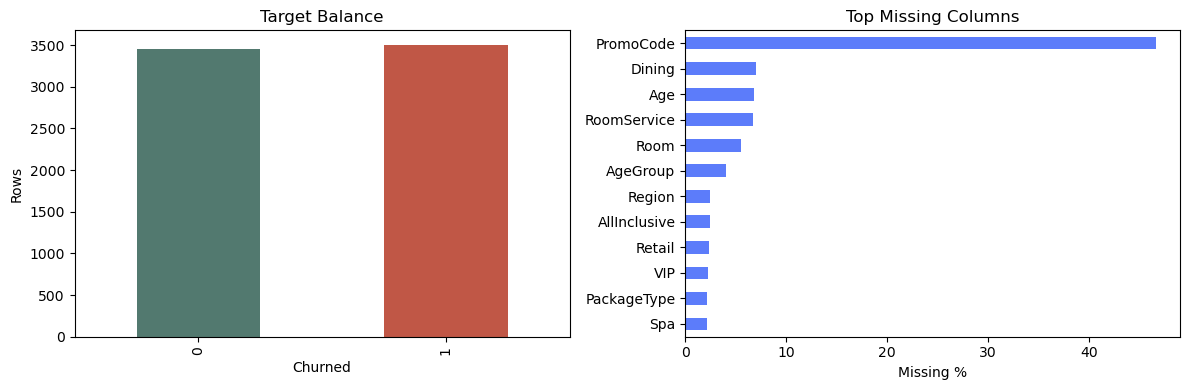

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train[TARGET].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#52796f", "#c05746"])
axes[0].set_title("Target Balance")
axes[0].set_xlabel("Churned")
axes[0].set_ylabel("Rows")

missing_summary.head(12).sort_values("missing_percent").plot(
    x="column",
    y="missing_percent",
    kind="barh",
    ax=axes[1],
    legend=False,
    color="#5c7cfa",
)
axes[1].set_title("Top Missing Columns")
axes[1].set_xlabel("Missing %")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 4. Feature Engineering

The custom transformer below is placed inside every sklearn pipeline. That keeps cleaning and feature engineering inside each CV fold and avoids leaking information from validation folds into training folds.

Main feature groups:

- booking date parts, recency, and weekend booking flags
- room deck, room number, room side, and room-number bands from values such as `G/630/S`
- promotion usage and explicit missingness flags
- capped and log-transformed spend features to handle very large outliers
- total spend, spend mix, number of active spend categories, and loyalty-to-spend ratios
- age-derived groups and engagement bins

In [5]:
DEFAULT_SPEND_COLS = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]


class ResortFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, spend_cols=None, cap_quantile=0.995):
        self.spend_cols = spend_cols
        self.cap_quantile = cap_quantile

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.spend_cols_ = [c for c in (self.spend_cols or DEFAULT_SPEND_COLS) if c in X.columns]
        self.cap_values_ = {}

        for col in self.spend_cols_:
            values = pd.to_numeric(X[col], errors="coerce")
            cap = values.quantile(self.cap_quantile)
            if pd.isna(cap) or cap <= 0:
                cap = values.max()
            self.cap_values_[col] = cap

        if "BookingDate" in X.columns:
            booking_dates = pd.to_datetime(X["BookingDate"], errors="coerce")
            self.booking_min_ = booking_dates.min()
            self.booking_max_ = booking_dates.max()
        else:
            self.booking_min_ = pd.NaT
            self.booking_max_ = pd.NaT

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        original_columns = set(X.columns)

        # Preserve missingness as signal before imputing or replacing values.
        missing_flag_cols = [
            "PromoCode",
            "Region",
            "AllInclusive",
            "Room",
            "PackageType",
            "Age",
            "VIP",
            "AgeGroup",
        ]
        for col in missing_flag_cols:
            if col in X.columns:
                X[f"{col}_Missing"] = X[col].isna().astype(int)

        # Booking date features.
        if "BookingDate" in X.columns:
            dates = pd.to_datetime(X["BookingDate"], errors="coerce")
            X["BookingYear"] = dates.dt.year
            X["BookingMonth"] = dates.dt.month
            X["BookingQuarter"] = dates.dt.quarter
            X["BookingDayOfWeek"] = dates.dt.dayofweek
            X["BookingDayOfMonth"] = dates.dt.day
            X["BookingIsWeekend"] = dates.dt.dayofweek.isin([5, 6]).astype(int)
            X["BookingDaysFromStart"] = (dates - self.booking_min_).dt.days
            X["BookingDaysBeforeLatestTrainDate"] = (self.booking_max_ - dates).dt.days

        # Room format is usually Deck/Number/Side, for example G/630/S.
        if "Room" in X.columns:
            room = X["Room"].astype("string")
            parts = room.str.split("/", expand=True)

            def room_part(index, default="Unknown"):
                if parts.shape[1] > index:
                    values = parts[index].astype("string")
                    return values.where(values.notna() & (values != ""), default).astype("object")
                return pd.Series(default, index=X.index, dtype="object")

            X["RoomDeck"] = room_part(0)
            X["RoomNumber"] = pd.to_numeric(room_part(1, default=np.nan), errors="coerce")
            X["RoomSide"] = room_part(2)
            X["RoomNumberBand"] = pd.cut(
                X["RoomNumber"],
                bins=[-np.inf, 100, 500, 1000, 1500, np.inf],
                labels=["000-100", "101-500", "501-1000", "1001-1500", "1501+"],
            ).astype("object")
            X["RoomNumberBand"] = X["RoomNumberBand"].where(X["RoomNumberBand"].notna(), "Unknown")
            X["RoomKnown"] = room.notna().astype(int)

        # Promotion features.
        if "PromoCode" in X.columns:
            promo = X["PromoCode"].astype("string").fillna("NoPromo")
            X["PromoCode"] = promo.astype("object")
            X["HasPromo"] = (promo != "NoPromo").astype(int)

        # Numeric cleanup for known binary or continuous columns.
        for col in ["AllInclusive", "VIP", "Age", "LoyaltyPoints", "SurveyScore", "DaysSinceEmail"]:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")

        # Age-derived features.
        if "Age" in X.columns:
            age = pd.to_numeric(X["Age"], errors="coerce")
            X["AgeGroupFromAge"] = pd.cut(
                age,
                bins=[-np.inf, 17, 25, 39, 59, np.inf],
                labels=["Minor", "Young", "Middle", "Senior", "Elderly"],
            ).astype("object")
            X["AgeGroupFromAge"] = X["AgeGroupFromAge"].where(X["AgeGroupFromAge"].notna(), "Unknown")
            X["IsMinor"] = (age < 18).astype(float)
            X["IsSeniorOrOlder"] = (age >= 40).astype(float)

        # Email engagement bins.
        if "DaysSinceEmail" in X.columns:
            days = pd.to_numeric(X["DaysSinceEmail"], errors="coerce")
            X["EmailRecencyBand"] = pd.cut(
                days,
                bins=[-np.inf, 30, 90, 180, 365, np.inf],
                labels=["0-30", "31-90", "91-180", "181-365", "365+"],
            ).astype("object")
            X["EmailRecencyBand"] = X["EmailRecencyBand"].where(X["EmailRecencyBand"].notna(), "Unknown")

        # Capped and log-transformed spend features.
        spend_frame = pd.DataFrame(index=X.index)
        for col in self.spend_cols_:
            raw = pd.to_numeric(X[col], errors="coerce")
            X[f"{col}_Missing"] = raw.isna().astype(int)
            cap = self.cap_values_.get(col, raw.quantile(self.cap_quantile))
            capped = raw.clip(lower=0, upper=cap).fillna(0)
            spend_frame[col] = capped
            X[f"{col}_Clipped"] = capped
            X[f"{col}_Log1p"] = np.log1p(capped)
            X[f"{col}_Used"] = (capped > 0).astype(int)

        if len(spend_frame.columns) > 0:
            X["TotalSpend"] = spend_frame.sum(axis=1)
            X["TotalSpendLog1p"] = np.log1p(X["TotalSpend"])
            X["SpendCategoriesUsed"] = (spend_frame > 0).sum(axis=1)
            X["AverageSpendWhenActive"] = X["TotalSpend"] / X["SpendCategoriesUsed"].replace(0, np.nan)
            X["AverageSpendWhenActive"] = X["AverageSpendWhenActive"].fillna(0)

            food_cols = [c for c in ["RoomService", "Dining"] if c in spend_frame.columns]
            leisure_cols = [c for c in ["Spa", "Entertainment"] if c in spend_frame.columns]
            X["FoodSpend"] = spend_frame[food_cols].sum(axis=1) if food_cols else 0
            X["LeisureSpend"] = spend_frame[leisure_cols].sum(axis=1) if leisure_cols else 0
            X["FoodSpendShare"] = X["FoodSpend"] / X["TotalSpend"].replace(0, np.nan)
            X["LeisureSpendShare"] = X["LeisureSpend"] / X["TotalSpend"].replace(0, np.nan)
            X["FoodSpendShare"] = X["FoodSpendShare"].fillna(0)
            X["LeisureSpendShare"] = X["LeisureSpendShare"].fillna(0)

        if "LoyaltyPoints" in X.columns:
            loyalty = pd.to_numeric(X["LoyaltyPoints"], errors="coerce")
            if "Age" in X.columns:
                age = pd.to_numeric(X["Age"], errors="coerce")
                X["LoyaltyPointsPerAge"] = loyalty / (age.clip(lower=0).fillna(age.median()) + 1)
            if "TotalSpend" in X.columns:
                X["LoyaltyPointsPerSpend"] = loyalty / (X["TotalSpend"] + 1)

        if {"SurveyScore", "DaysSinceEmail"}.issubset(original_columns):
            X["SurveyScoreTimesEmailGap"] = (
                pd.to_numeric(X["SurveyScore"], errors="coerce")
                * pd.to_numeric(X["DaysSinceEmail"], errors="coerce")
            )

        # Replace missing categorical values with explicit labels.
        categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns
        for col in categorical_cols:
            values = X[col].astype("object")
            X[col] = values.where(pd.notna(values), "Unknown")

        # Do not train on arbitrary identifiers or raw columns after extracting useful signal.
        drop_cols = [ID_COLUMN, "BookingDate", "Room"] + self.spend_cols_
        X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

        return X

In [6]:
feature_preview = ResortFeatureEngineer().fit_transform(train.drop(columns=[TARGET]))
print(f"Engineered feature matrix preview shape: {feature_preview.shape}")
display(feature_preview.head())

engineered_types = pd.DataFrame(
    {
        "column": feature_preview.columns,
        "dtype": feature_preview.dtypes.astype(str).values,
    }
)
display(engineered_types.head(30))

Engineered feature matrix preview shape: (6954, 69)


,PromoCode,Region,AllInclusive,PackageType,Age,VIP,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,...,TotalSpendLog1p,SpendCategoriesUsed,AverageSpendWhenActive,FoodSpend,LeisureSpend,FoodSpendShare,LeisureSpendShare,LoyaltyPointsPerAge,LoyaltyPointsPerSpend,SurveyScoreTimesEmailGap
0,NoPromo,Americas,0.0,Relaxation,0.0,0.0,6915,5,136,Website,...,0.000000,0,0.000000,0.000000,0.0,0.0,0.000000,6915.000000,6915.000000,680
1,NoPromo,Americas,1.0,Relaxation,17.0,0.0,8571,5,362,Corporate,...,0.000000,0,0.000000,0.000000,0.0,0.0,0.000000,476.166667,8571.000000,1810
2,NoPromo,Americas,NaN,Wellness,35.0,0.0,1142,4,154,TravelAgent,...,12.726415,1,336519.843643,336519.843643,0.0,1.0,0.000000,31.722222,0.003394,616
3,PromoA,Europe,1.0,Adventure,26.0,0.0,9642,2,128,Website,...,0.000000,0,0.000000,0.000000,0.0,0.0,0.000000,357.111111,9642.000000,256
4,PromoA,Americas,0.0,Relaxation,13.0,0.0,5528,4,35,Mobile,...,8.558143,3,1736.000000,0.000000,5148.0,0.0,0.988479,394.857143,1.061240,140


,column,dtype
0,PromoCode,object
1,Region,object
2,AllInclusive,float64
3,PackageType,object
4,Age,float64
5,VIP,float64
6,LoyaltyPoints,int64
7,SurveyScore,int64
8,DaysSinceEmail,int64
9,BookingChannel,object


## 5. Modeling Pipeline

The preprocessing layer imputes numeric values, robust-scales numeric features, imputes categorical values, and one-hot encodes categorical values. The feature engineering step stays inside the pipeline so the exact same transformations are applied to train, validation, and test data.

In [7]:
def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=0.02,
                    sparse_output=False,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number)),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_modeling_pipeline(model) -> Pipeline:
    return Pipeline(
        steps=[
            ("features", ResortFeatureEngineer()),
            ("preprocess", make_preprocessor()),
            ("model", model),
        ]
    )


X = train.drop(columns=[TARGET])
y = train[TARGET].astype(int)

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

## 6. Compare Candidate Algorithms

This step selects the algorithm family before hyperparameter tuning. ROC AUC is used for selection because it measures probability ranking quality across possible thresholds. F1 and accuracy are also reported.

The notebook defaults to 3-fold CV and 8 Optuna trials so it runs quickly. For a final competition-style run, increase `CV_SPLITS` to 5 and `N_TRIALS` to 30 or more.

In [8]:
candidate_models = {
    "logistic_regression": LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=100,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=120,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
}

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
}

comparison_rows = []
for model_name, model in candidate_models.items():
    print(f"Evaluating {model_name}...")
    pipeline = make_modeling_pipeline(model)
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    comparison_rows.append(
        {
            "model": model_name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
            "f1_mean": scores["test_f1"].mean(),
            "accuracy_mean": scores["test_accuracy"].mean(),
        }
    )

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)
display(comparison)

best_model_name = comparison.loc[0, "model"]
print(f"Selected algorithm for Optuna tuning: {best_model_name}")

Evaluating logistic_regression...
Evaluating random_forest...
Evaluating extra_trees...
Evaluating hist_gradient_boosting...


,model,roc_auc_mean,roc_auc_std,f1_mean,accuracy_mean
0,hist_gradient_boosting,0.918934,0.002099,0.836021,0.837216
1,random_forest,0.901566,0.001691,0.815359,0.816077
2,logistic_regression,0.900510,0.001402,0.819553,0.818090
3,extra_trees,0.899863,0.000657,0.809086,0.813920


Selected algorithm for Optuna tuning: hist_gradient_boosting


## 7. Tune The Selected Algorithm With Optuna CV

Optuna searches hyperparameters for the selected algorithm. Each trial builds a fresh pipeline and evaluates it with the same stratified CV folds used in the comparison step.

In [9]:
def suggest_model(trial: optuna.Trial, model_name: str):
    if model_name == "logistic_regression":
        return LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 1e2, log=True),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            max_iter=5000,
            random_state=RANDOM_STATE,
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 50, 200, step=50),
            max_depth=trial.suggest_categorical("max_depth", [None, 6, 10, 14, 18, 24, 32]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 30),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 12),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.4, 0.6, 0.8, None]),
            bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "extra_trees":
        return ExtraTreesClassifier(
            n_estimators=trial.suggest_int("n_estimators", 50, 200, step=50),
            max_depth=trial.suggest_categorical("max_depth", [None, 6, 10, 14, 18, 24, 32]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 30),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 12),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.4, 0.6, 0.8, None]),
            bootstrap=trial.suggest_categorical("bootstrap", [True, False]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
            max_iter=trial.suggest_int("max_iter", 50, 200, step=50),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 7, 63),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 80),
            l2_regularization=trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
            max_bins=trial.suggest_int("max_bins", 64, 255),
            random_state=RANDOM_STATE,
        )

    raise ValueError(f"Unknown model name: {model_name}")


def objective(trial: optuna.Trial) -> float:
    model = suggest_model(trial, best_model_name)
    pipeline = make_modeling_pipeline(model)
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1,
    )
    return scores.mean()


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Best CV ROC AUC: {study.best_value:.5f}")
print("Best hyperparameters:")
display(pd.Series(study.best_params).to_frame("value"))

optuna_trials = study.trials_dataframe().sort_values("value", ascending=False)
display(optuna_trials.head(10))

  0%|          | 0/8 [00:00<?, ?it/s]

Best CV ROC AUC: 0.92209
Best hyperparameters:


,value
learning_rate,0.039207
max_iter,200.000000
max_leaf_nodes,18.000000
min_samples_leaf,46.000000
l2_regularization,0.091637
max_bins,72.000000


,number,value,datetime_start,datetime_complete,duration,params_l2_regularization,params_learning_rate,params_max_bins,params_max_iter,params_max_leaf_nodes,params_min_samples_leaf,state
4,4,0.922094,2026-05-25 15:37:22.367866,2026-05-25 15:37:31.051165,0 days 00:00:08.683299,0.091637,0.039207,72,200,18,46,COMPLETE
2,2,0.919311,2026-05-25 15:37:10.132165,2026-05-25 15:37:12.497960,0 days 00:00:02.365795,0.003321,0.121069,164,50,17,23,COMPLETE
0,0,0.917817,2026-05-25 15:36:32.806268,2026-05-25 15:36:53.209499,0 days 00:00:20.403231,0.000603,0.030711,93,200,48,52,COMPLETE
3,3,0.914856,2026-05-25 15:37:12.498356,2026-05-25 15:37:22.367142,0 days 00:00:09.868786,0.002889,0.036473,134,100,41,19,COMPLETE
1,1,0.906630,2026-05-25 15:36:53.210351,2026-05-25 15:37:10.131736,0 days 00:00:16.921385,0.000127,0.011901,250,200,41,60,COMPLETE
7,7,0.905257,2026-05-25 15:37:37.918415,2026-05-25 15:37:47.220250,0 days 00:00:09.301835,0.003619,0.011085,163,200,21,57,COMPLETE
5,5,0.904356,2026-05-25 15:37:31.051942,2026-05-25 15:37:32.777604,0 days 00:00:01.725662,6.732249,0.061721,219,50,10,77,COMPLETE
6,6,0.893845,2026-05-25 15:37:32.778232,2026-05-25 15:37:37.918003,0 days 00:00:05.139771,0.000408,0.024906,159,50,46,41,COMPLETE


## 8. Validate The Tuned Model And Pick A Threshold

The final output must be 0 or 1. The model naturally produces churn probabilities, so this section uses out-of-fold predictions to select a threshold that maximizes F1 on validation folds.

In [10]:
tuned_model = suggest_model(optuna.trial.FixedTrial(study.best_params), best_model_name)
tuned_pipeline = make_modeling_pipeline(tuned_model)

oof_proba = cross_val_predict(
    tuned_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

threshold_grid = np.linspace(0.05, 0.95, 181)
threshold_scores = pd.DataFrame(
    {
        "threshold": threshold_grid,
        "f1": [f1_score(y, (oof_proba >= t).astype(int)) for t in threshold_grid],
        "accuracy": [accuracy_score(y, (oof_proba >= t).astype(int)) for t in threshold_grid],
        "precision": [precision_score(y, (oof_proba >= t).astype(int), zero_division=0) for t in threshold_grid],
        "recall": [recall_score(y, (oof_proba >= t).astype(int), zero_division=0) for t in threshold_grid],
    }
)

best_threshold = float(threshold_scores.sort_values("f1", ascending=False).iloc[0]["threshold"])
oof_pred = (oof_proba >= best_threshold).astype(int)

print(f"OOF ROC AUC:   {roc_auc_score(y, oof_proba):.5f}")
print(f"Best threshold: {best_threshold:.3f}")
print(f"OOF F1:        {f1_score(y, oof_pred):.5f}")
print(f"OOF Accuracy:  {accuracy_score(y, oof_pred):.5f}")
print(f"OOF Precision: {precision_score(y, oof_pred):.5f}")
print(f"OOF Recall:    {recall_score(y, oof_pred):.5f}")
print()
print(classification_report(y, oof_pred))
display(pd.DataFrame(confusion_matrix(y, oof_pred), index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]))

display(threshold_scores.sort_values("f1", ascending=False).head(10))

OOF ROC AUC:   0.92204
Best threshold: 0.410
OOF F1:        0.84523
OOF Accuracy:  0.83880
OOF Precision: 0.81823
OOF Recall:    0.87407

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      3452
           1       0.82      0.87      0.85      3502

    accuracy                           0.84      6954
   macro avg       0.84      0.84      0.84      6954
weighted avg       0.84      0.84      0.84      6954



,pred_0,pred_1
actual_0,2772,680
actual_1,441,3061


,threshold,f1,accuracy,precision,recall
72,0.410,0.845230,0.838798,0.818230,0.874072
71,0.405,0.845222,0.838366,0.816223,0.876356
73,0.415,0.844992,0.839085,0.820554,0.870931
70,0.400,0.844970,0.837791,0.814520,0.877784
74,0.420,0.844840,0.839373,0.822559,0.868361
69,0.395,0.844816,0.837072,0.811793,0.880640
68,0.390,0.844493,0.836353,0.809748,0.882353
67,0.385,0.844287,0.835778,0.807933,0.884066
75,0.425,0.844129,0.839085,0.824041,0.865220
66,0.380,0.844094,0.835059,0.805447,0.886636


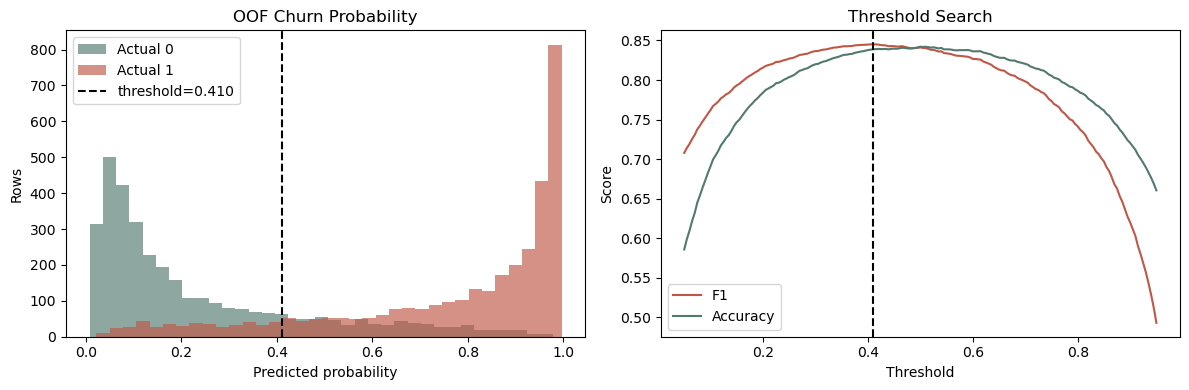

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(oof_proba[y == 0], bins=35, alpha=0.65, label="Actual 0", color="#52796f")
axes[0].hist(oof_proba[y == 1], bins=35, alpha=0.65, label="Actual 1", color="#c05746")
axes[0].axvline(best_threshold, color="black", linestyle="--", label=f"threshold={best_threshold:.3f}")
axes[0].set_title("OOF Churn Probability")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Rows")
axes[0].legend()

axes[1].plot(threshold_scores["threshold"], threshold_scores["f1"], label="F1", color="#c05746")
axes[1].plot(threshold_scores["threshold"], threshold_scores["accuracy"], label="Accuracy", color="#52796f")
axes[1].axvline(best_threshold, color="black", linestyle="--")
axes[1].set_title("Threshold Search")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Train Final Model And Create Submission

The final model is fit on the full training dataset using the tuned algorithm and hyperparameters. Predictions for the test dataset are written to `submission.csv` as integer 0/1 labels.

In [12]:
final_model = suggest_model(optuna.trial.FixedTrial(study.best_params), best_model_name)
final_pipeline = make_modeling_pipeline(final_model)
final_pipeline.fit(X, y)

test_proba = final_pipeline.predict_proba(test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

submission = pd.DataFrame(
    {
        ID_COLUMN: test[ID_COLUMN].astype(int),
        TARGET: test_pred.astype(int),
    }
)
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved {len(submission):,} predictions to {SUBMISSION_PATH.resolve()}")
display(submission.head(10))
display(submission[TARGET].value_counts().sort_index().rename("prediction_count").to_frame())

Saved 1,739 predictions to /Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/25 May Full AI - Codex/submission.csv


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,0
4,635228,0
5,844514,0
6,541503,1
7,787572,1
8,645651,0
9,849608,1


,prediction_count
Churned,
0,828
1,911


## 10. Optional Model Interpretation

For tree ensembles and linear models, the cell below shows the most influential engineered/model-ready features. If the selected model does not expose direct importances, the cell will skip gracefully.

In [13]:
fitted_preprocessor = final_pipeline.named_steps["preprocess"]
fitted_model = final_pipeline.named_steps["model"]

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{i}" for i in range(final_pipeline[:-1].transform(X).shape[1])])

importance_df = None
if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": fitted_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
elif hasattr(fitted_model, "coef_"):
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": np.abs(fitted_model.coef_[0]),
        }
    ).sort_values("importance", ascending=False)

if importance_df is None:
    print(f"{type(fitted_model).__name__} does not expose direct feature importances.")
else:
    display(importance_df.head(25))

HistGradientBoostingClassifier does not expose direct feature importances.


## Notes For Further Improvement

- Increase `N_TRIALS` for a deeper Optuna search if runtime is not a concern.
- If the scoring metric for a competition or assignment is known, replace ROC AUC/F1 with that metric.
- Try calibrated probabilities if the final threshold is important operationally.
- Consider ensembling the top two model families if their CV scores are close.